# Agri ETF Adaptive Market-State Learning — Refactored Notebook

This notebook keeps the research flow but moves reusable function definitions into Python modules under `agri_market_state/`.

Core idea: learn when agri commodity-linked ETFs are better handled as trend-following, momentum-following, mean-reverting, or abstention states using price-path features, PCA latent states, walk-forward validation, and benchmark baselines.

In [72]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make local package importable when the notebook sits next to agri_market_state/.
PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from agri_market_state import (
    ResearchConfig,
    RANDOM_STATE,
    ACTION_COLS,
    load_data,
    build_model_base,
    get_feature_columns,
    prepare_model_frame,
    fit_exploratory_pca,
    add_pca_regimes,
    fixed_action_summary,
    daily_portfolio_returns,
    summarize_daily_returns,
    walk_forward_adaptive_policy,
    regime_interpretation,
    run_cost_sensitivity,
    block_bootstrap_paths,
    monte_carlo_summary,
)

from agri_market_state.baselines import BaselineConfig, build_baseline_report, robustness_table

## 1. Configuration

Use `DATA_MODE='synthetic'` for a fully offline test. Switch to `DATA_MODE='yfinance'` for real ETF data when internet and `yfinance` are available.

In [73]:
cfg = ResearchConfig(
    DATA_MODE="synthetic",  # synthetic, yfinance, csv
    START_DATE="2016-01-01",
    TRADE_TICKERS=("DBA", "WEAT", "CORN", "SOYB", "CANE"),
    CONTEXT_TICKERS=("DBC", "UUP", "USO"),
    HORIZON_DAYS=5,
    EVENT_ONLY=True,
    DISLOCATION_Z_THRESHOLD=1.5,
    MOMENTUM_Z_THRESHOLD=1.0,
    RANGE_SHOCK_THRESHOLD=1.5,
    TRAIN_DAYS=252,
    TEST_DAYS=126,
    STEP_DAYS=126,
    N_PCA_COMPONENTS=3,
    N_CLUSTERS=4,
    MIN_EDGE_BPS=2.0,
    COST_BPS=5.0,
    RUN_VAE=True,
    RUN_COST_SENSITIVITY=True,
    SYNTHETIC_PERIODS=900,
)
cfg

ResearchConfig(DATA_MODE='synthetic', LOCAL_CSV_PATH='agri_etf_ohlcv.csv', START_DATE='2016-01-01', END_DATE=None, TRADE_TICKERS=('DBA', 'WEAT', 'CORN', 'SOYB', 'CANE'), CONTEXT_TICKERS=('DBC', 'UUP', 'USO'), HORIZON_DAYS=5, EVENT_ONLY=True, DISLOCATION_Z_THRESHOLD=1.5, MOMENTUM_Z_THRESHOLD=1.0, RANGE_SHOCK_THRESHOLD=1.5, TRAIN_DAYS=252, TEST_DAYS=126, STEP_DAYS=126, N_PCA_COMPONENTS=3, N_CLUSTERS=4, MIN_EDGE_BPS=2.0, COST_BPS=5.0, RUN_VAE=True, RUN_COST_SENSITIVITY=True, SYNTHETIC_PERIODS=900)

## 2. Load OHLCV data

The expected schema after normalization is `date, symbol, open, high, low, close, volume`.

In [74]:
raw_df = load_data(cfg)
print(raw_df.shape)
raw_df.head()

(7200, 7)


,date,symbol,open,high,low,close,volume
0,2016-01-01,CANE,25.003713,25.087459,24.920423,25.004168,209271
1,2016-01-04,CANE,24.964432,25.638104,24.737722,25.407371,130439
2,2016-01-05,CANE,25.381442,25.923031,25.177403,25.716299,317506
3,2016-01-06,CANE,25.793322,26.015232,25.669227,25.890669,1489875
4,2016-01-07,CANE,25.896027,26.131556,25.659311,25.894830,238042


## 3. Build trend, momentum, mean-reversion and context features

In [75]:
model_base = build_model_base(
    raw_df,
    trade_tickers=cfg.TRADE_TICKERS,
    context_tickers=cfg.CONTEXT_TICKERS,
    horizons=(1, 3, 5, 10),
)
print(model_base.shape)
model_base.head()

(4500, 53)


,date,symbol,open,high,low,close,volume,daily_return,log_return,fwd_return_1d,...,agri_abs_move_median,ctx_DBC_return,ctx_DBC_return_5d,ctx_DBC_vol_20,ctx_UUP_return,ctx_UUP_return_5d,ctx_UUP_vol_20,ctx_USO_return,ctx_USO_return_5d,ctx_USO_vol_20
0,2016-01-01,CANE,25.003713,25.087459,24.920423,25.004168,209271,NaN,NaN,0.017743,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-04,CANE,24.964432,25.638104,24.737722,25.407371,130439,0.016125,0.015997,0.013193,...,0.004943,0.009079,NaN,NaN,0.000362,NaN,NaN,0.005971,NaN,NaN
2,2016-01-05,CANE,25.381442,25.923031,25.177403,25.716299,317506,0.012159,0.012086,0.003774,...,0.002228,-0.001667,NaN,NaN,0.003517,NaN,NaN,0.025532,NaN,NaN
3,2016-01-06,CANE,25.793322,26.015232,25.669227,25.890669,1489875,0.006781,0.006758,-0.000046,...,0.004392,-0.008786,NaN,NaN,0.004223,NaN,NaN,0.003539,NaN,NaN
4,2016-01-07,CANE,25.896027,26.131556,25.659311,25.894830,238042,0.000161,0.000161,-0.002505,...,0.005207,0.024912,NaN,NaN,-0.003393,NaN,NaN,0.024451,NaN,NaN


## 4. Add event flags and candidate action returns

Actions:

- `FOLLOW_TREND`
- `FOLLOW_MOMENTUM`
- `MEAN_REVERT`
- `ABSTAIN`

In [76]:
FEATURE_COLS = get_feature_columns(model_base)
model_df = prepare_model_frame(model_base, cfg, FEATURE_COLS)

print("Rows:", len(model_df))
print("Symbols:", model_df["symbol"].nunique())
print("Dates:", model_df["date"].nunique())
print("Feature count:", len(FEATURE_COLS))
model_df[["date", "symbol", "event_flag", "trend_score", "momentum_score", "dislocation_zscore_20", "range_shock_20", "oracle_best_action"]].head()

Rows: 3038
Symbols: 5
Dates: 832
Feature count: 33


,date,symbol,event_flag,trend_score,momentum_score,dislocation_zscore_20,range_shock_20,oracle_best_action
0,2016-03-25,CANE,True,-0.013113,0.705783,0.086320,1.753744,FOLLOW_MOMENTUM
1,2016-03-25,CORN,True,0.023622,4.147708,1.818237,0.266910,MEAN_REVERT
2,2016-03-25,DBA,True,-0.024379,2.543291,1.171518,0.980736,FOLLOW_MOMENTUM
3,2016-03-25,SOYB,True,0.013812,1.616547,1.274883,0.828529,FOLLOW_TREND
4,2016-03-25,WEAT,True,-0.007833,5.796993,2.312025,1.801594,FOLLOW_MOMENTUM


## 5. Exploratory PCA market-state projection

This PCA is descriptive. The walk-forward policy later fits PCA inside each training fold to avoid look-ahead.

In [77]:
pca_pipe, pcs = fit_exploratory_pca(model_df, FEATURE_COLS, cfg.N_PCA_COMPONENTS)
print("Explained variance:", np.round(pca_pipe.named_steps["pca"].explained_variance_ratio_, 4))

model_df = add_pca_regimes(model_df, pcs, cfg.N_CLUSTERS, RANDOM_STATE)
model_df.groupby("pca_regime")[ACTION_COLS + ["trend_score", "momentum_score", "dislocation_zscore_20", "range_shock_20"]].mean().round(4)

Explained variance: [0.3049 0.09   0.078 ]


,FOLLOW_TREND_return,FOLLOW_MOMENTUM_return,MEAN_REVERT_return,ABSTAIN_return,trend_score,momentum_score,dislocation_zscore_20,range_shock_20
pca_regime,,,,,,,,
0,0.0018,0.0004,-0.0035,0.0,-0.0352,-2.1157,-1.4671,1.1819
1,0.0005,-0.0007,-0.0015,0.0,0.0358,2.4296,1.5382,1.2610
2,-0.0000,-0.0027,0.0026,0.0,0.0149,-1.6500,-0.7751,1.0937
3,0.0001,-0.0005,-0.0014,0.0,-0.0068,1.7447,0.9341,1.1138


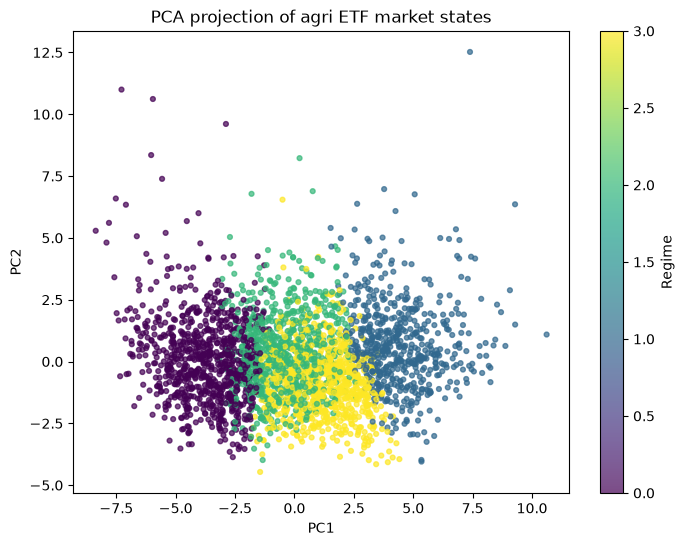

In [78]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(model_df["PC1"], model_df["PC2"], c=model_df["pca_regime"], s=12, alpha=0.7)
plt.title("PCA projection of agri ETF market states")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Regime")
plt.show()

## 6. Fixed-action baseline summary

These are simple non-adaptive baselines.

In [79]:
baseline_summary_df = fixed_action_summary(model_df, ACTION_COLS)
baseline_summary_df

,strategy,n_days,mean_daily_return,ann_return_approx,ann_vol_approx,sharpe_approx,cumulative_return,max_drawdown,positive_day_rate
0,FOLLOW_TREND,832,0.000931,0.234558,0.241263,0.972207,0.971674,-0.571840,0.518029
1,FOLLOW_MOMENTUM,832,-0.000803,-0.202394,0.240211,-0.842566,-0.534400,-0.654167,0.463942
2,MEAN_REVERT,832,-0.000938,-0.236334,0.236754,-0.998224,-0.582180,-0.672488,0.461538
3,ABSTAIN,832,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000


## 7. Actual adaptive policy

The actual implementation learns expected action returns in walk-forward folds and abstains when the best predicted edge is too small.

In [80]:
adaptive_output = walk_forward_adaptive_policy(model_df, FEATURE_COLS, ACTION_COLS, cfg)
print(adaptive_output.shape)
adaptive_output.head()

(2098, 17)


,date,symbol,FOLLOW_TREND_return,FOLLOW_MOMENTUM_return,MEAN_REVERT_return,ABSTAIN_return,pred_FOLLOW_TREND,pred_FOLLOW_MOMENTUM,pred_MEAN_REVERT,pred_ABSTAIN,selected_action,predicted_edge,walkforward_regime,fold_PC1,fold_PC2,fold_PC3,adaptive_return
0,2017-03-15,CANE,0.041815,-0.042815,0.041815,0.0,-0.009084,-0.000350,-0.006326,0.0,ABSTAIN,0.000000,1,0.150303,2.093236,1.119141,0.000000
1,2017-03-15,DBA,0.037748,-0.038748,0.037748,0.0,0.002897,-0.002284,-0.004684,0.0,FOLLOW_TREND,0.002897,2,0.958019,0.364514,0.922971,0.037748
2,2017-03-15,SOYB,-0.003999,-0.003999,0.002999,0.0,-0.019202,0.001890,-0.005876,0.0,FOLLOW_MOMENTUM,0.001890,0,-4.323896,0.983980,-0.765152,-0.003999
3,2017-03-15,WEAT,-0.018180,-0.018180,0.017180,0.0,-0.012034,-0.001589,0.000751,0.0,MEAN_REVERT,0.000751,0,-2.862264,0.519854,-0.414177,0.017180
4,2017-03-16,CANE,0.009412,-0.010412,0.009412,0.0,-0.002486,-0.007515,0.005367,0.0,MEAN_REVERT,0.005367,1,-0.816606,0.671553,-1.291392,0.009412


In [81]:
adaptive_daily = daily_portfolio_returns(adaptive_output, "adaptive_return")
adaptive_summary = summarize_daily_returns(adaptive_daily, "ADAPTIVE_POLICY")
comparison = pd.concat([baseline_summary_df, pd.DataFrame([adaptive_summary])], ignore_index=True)
comparison

,strategy,n_days,mean_daily_return,ann_return_approx,ann_vol_approx,sharpe_approx,cumulative_return,max_drawdown,positive_day_rate
0,FOLLOW_TREND,832,0.000931,0.234558,0.241263,0.972207,0.971674,-0.571840,0.518029
1,FOLLOW_MOMENTUM,832,-0.000803,-0.202394,0.240211,-0.842566,-0.534400,-0.654167,0.463942
2,MEAN_REVERT,832,-0.000938,-0.236334,0.236754,-0.998224,-0.582180,-0.672488,0.461538
3,ABSTAIN,832,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
4,ADAPTIVE_POLICY,580,-0.000554,-0.139732,0.237895,-0.587368,-0.321424,-0.568888,0.500000


In [82]:
adaptive_output["selected_action"].value_counts(normalize=True).rename("share").to_frame()

,share
selected_action,
FOLLOW_TREND,0.331268
MEAN_REVERT,0.329361
FOLLOW_MOMENTUM,0.263108
ABSTAIN,0.076263


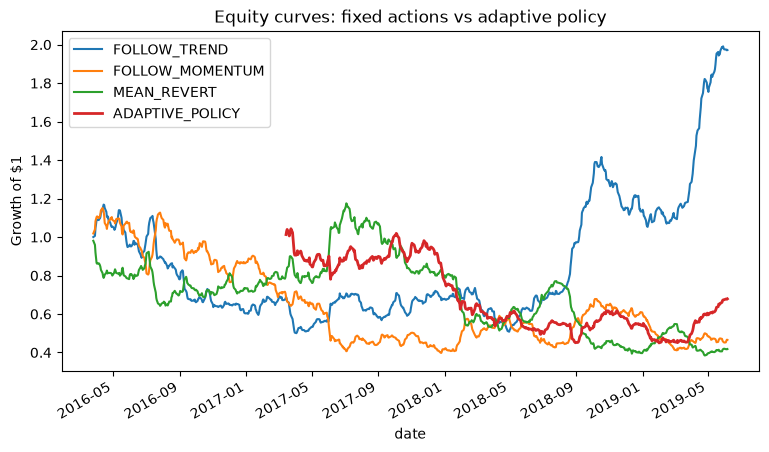

In [83]:
plt.figure(figsize=(9, 5))
for action_col in ["FOLLOW_TREND_return", "FOLLOW_MOMENTUM_return", "MEAN_REVERT_return"]:
    (1 + daily_portfolio_returns(model_df, action_col)).cumprod().plot(label=action_col.replace("_return", ""))
(1 + adaptive_daily).cumprod().plot(label="ADAPTIVE_POLICY", linewidth=2)
plt.title("Equity curves: fixed actions vs adaptive policy")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

## 8. Regime interpretation

In [84]:
regime_interpretation(adaptive_output).round(4)

,n,mean_adaptive_return,mean_predicted_edge,trend_share,momentum_share,mean_revert_share,abstain_share
walkforward_regime,,,,,,,
0,626,0.0031,0.0075,0.3466,0.2412,0.3211,0.0911
1,542,-0.0006,0.0065,0.3487,0.2288,0.3450,0.0775
2,478,-0.0007,0.0064,0.3536,0.3494,0.2322,0.0649
3,452,-0.0041,0.0078,0.2655,0.2434,0.4248,0.0664


## 9. Cost sensitivity

In [85]:
if cfg.RUN_COST_SENSITIVITY:
    cost_sensitivity = run_cost_sensitivity(cfg, model_base, FEATURE_COLS, costs=(0, 2, 5, 10, 20))
else:
    cost_sensitivity = pd.DataFrame({"note": ["Skipped by default. Set cfg.RUN_COST_SENSITIVITY=True to run."]})
cost_sensitivity

,strategy,n_days,mean_daily_return,ann_return_approx,ann_vol_approx,sharpe_approx,cumulative_return,max_drawdown,positive_day_rate,cost_bps
0,cost_0_bps,580,-0.000174,-0.043795,0.238774,-0.183416,-0.154046,-0.541870,0.531034,0
1,cost_2_bps,580,-0.000415,-0.104696,0.238263,-0.439414,-0.264532,-0.561719,0.518966,2
2,cost_5_bps,580,-0.000554,-0.139732,0.237895,-0.587368,-0.321424,-0.568888,0.500000,5
3,cost_10_bps,580,-0.000948,-0.238886,0.235413,-1.014753,-0.459276,-0.639852,0.477586,10
4,cost_20_bps,580,-0.001489,-0.375263,0.223853,-1.676379,-0.602665,-0.725336,0.446552,20


## 10. Monte Carlo block-bootstrap robustness

In [86]:
mc_paths = block_bootstrap_paths(adaptive_daily, n_paths=250, block_size=10, seed=RANDOM_STATE)
mc_summary = monte_carlo_summary(mc_paths)
mc_summary

terminal_mean     -0.241529
terminal_median   -0.363349
terminal_p05      -0.735192
terminal_p95       0.620886
prob_positive      0.196000
dtype: float64

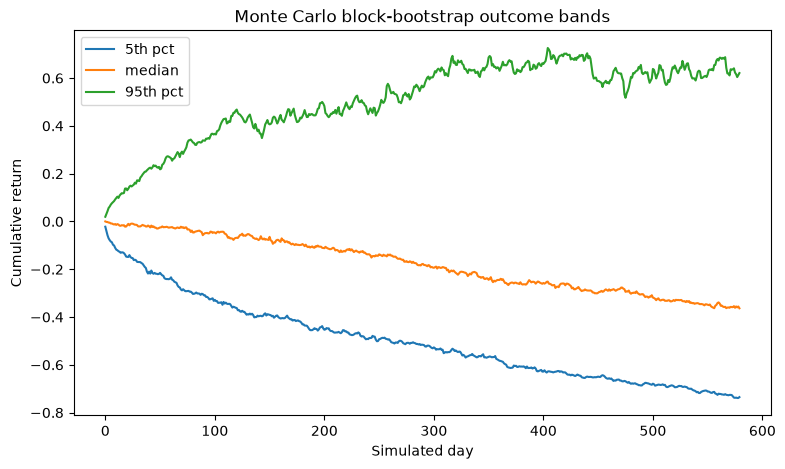

In [87]:
plt.figure(figsize=(9, 5))
for q, label in [(0.05, "5th pct"), (0.50, "median"), (0.95, "95th pct")]:
    mc_paths.quantile(q, axis=1).plot(label=label)
plt.title("Monte Carlo block-bootstrap outcome bands")
plt.xlabel("Simulated day")
plt.ylabel("Cumulative return")
plt.legend()
plt.show()

## 11. Full baseline benchmark suite

This section compares the actual implementation against transparent baselines: rule-based market state, symbol memory, PCA-regime memory, no-projection ML, random-action diagnostic, and oracle diagnostic.

In [88]:
baseline_cfg = BaselineConfig(
    train_days=cfg.TRAIN_DAYS,
    test_days=cfg.TEST_DAYS,
    n_pca_components=cfg.N_PCA_COMPONENTS,
    n_pca_bins=cfg.N_CLUSTERS,
    min_edge_bps=cfg.MIN_EDGE_BPS,
    random_state=RANDOM_STATE,
)

baseline_report, baseline_outputs = build_baseline_report(
    model_df=model_df,
    action_cols=ACTION_COLS,
    feature_cols=FEATURE_COLS,
    cfg=baseline_cfg,
    adaptive_output=adaptive_output,
)
baseline_report

,strategy,n_days,mean_daily_return,ann_return_approx,ann_vol_approx,sharpe_approx,cumulative_return,max_drawdown,positive_day_rate
0,ORACLE_BEST_DIAGNOSTIC,832,0.019297,4.862939,0.160591,30.281520,7.741690e+06,0.000000,1.000000
1,FIXED_FOLLOW_TREND,832,0.000931,0.234558,0.241263,0.972207,9.716739e-01,-0.571840,0.518029
2,WF_SYMBOL_BEST_ACTION,580,0.000938,0.236392,0.197602,1.196302,6.473951e-01,-0.371216,0.510345
3,RANDOM_ACTION_DIAGNOSTIC,832,0.000302,0.076175,0.208554,0.365254,1.978318e-01,-0.330566,0.480769
4,FIXED_ABSTAIN,832,0.000000,0.000000,0.000000,NaN,0.000000e+00,0.000000,0.000000
5,WF_NO_PROJECTION_ML,580,-0.000386,-0.097277,0.231294,-0.420576,-2.489543e-01,-0.595177,0.496552
6,ACTUAL_ADAPTIVE_POLICY,580,-0.000554,-0.139732,0.237895,-0.587368,-3.214238e-01,-0.568888,0.500000
7,WF_PCA_REGIME_BEST_ACTION,580,-0.000825,-0.208000,0.205363,-1.012842,-4.099175e-01,-0.663583,0.443103
8,RULE_MARKET_STATE,832,-0.000633,-0.159525,0.235163,-0.678356,-4.607069e-01,-0.558005,0.484375
9,FIXED_FOLLOW_MOMENTUM,832,-0.000803,-0.202394,0.240211,-0.842566,-5.343999e-01,-0.654167,0.463942


In [89]:
baseline_outputs['FIXED_MEAN_REVERT'].columns

Index(['date', 'symbol', 'open', 'high', 'low', 'close', 'volume',
       'daily_return', 'log_return', 'fwd_return_1d', 'fwd_return_3d',
       'fwd_return_5d', 'fwd_return_10d', 'sma_10', 'sma_20', 'sma_60',
       'trend_score', 'trend_slope_20', 'price_vs_sma60', 'ret_20', 'ret_60',
       'ret_5', 'ret_10', 'momentum_score', 'momentum_20_score',
       'dislocation_zscore_20', 'dislocation_zscore_60', 'rsi_14',
       'rsi_centered', 'atr_14_pct', 'range_pct', 'range_shock_20',
       'parkinson_vol_20', 'parkinson_vol_60', 'volume_zscore_20',
       'drawdown_60', 'distance_from_60d_low', 'trend_dir', 'momentum_dir',
       'mean_reversion_dir', 'agri_basket_return', 'agri_cross_dispersion',
       'agri_positive_breadth', 'agri_abs_move_median', 'ctx_DBC_return',
       'ctx_DBC_return_5d', 'ctx_DBC_vol_20', 'ctx_UUP_return',
       'ctx_UUP_return_5d', 'ctx_UUP_vol_20', 'ctx_USO_return',
       'ctx_USO_return_5d', 'ctx_USO_vol_20', 'event_flag',
       'FOLLOW_TREND_return', '

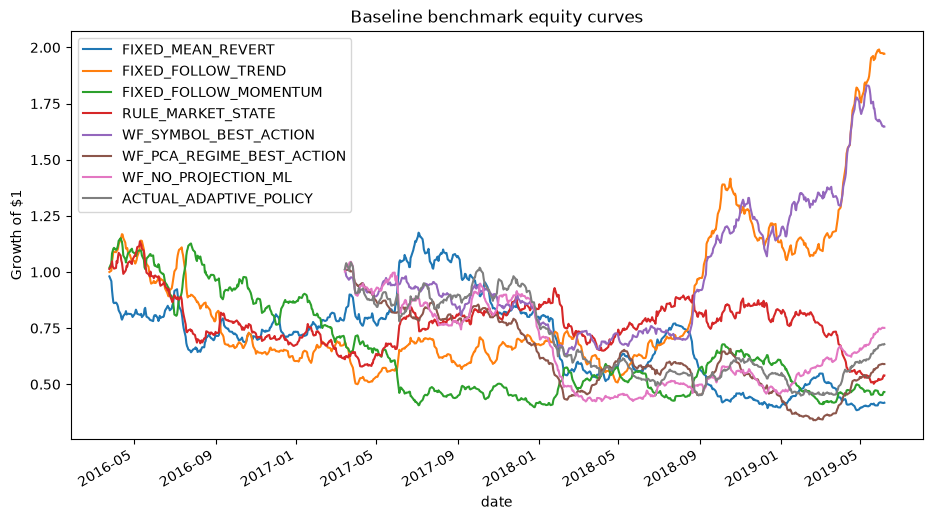

In [90]:
plot_names = [
    "FIXED_MEAN_REVERT",
    "FIXED_FOLLOW_TREND",
    "FIXED_FOLLOW_MOMENTUM",
    "RULE_MARKET_STATE",
    "WF_SYMBOL_BEST_ACTION",
    "WF_PCA_REGIME_BEST_ACTION",
    "WF_NO_PROJECTION_ML",
    "ACTUAL_ADAPTIVE_POLICY",
]
plt.figure(figsize=(11, 6))
for name in plot_names:
    if name not in baseline_outputs:
        continue
    out = baseline_outputs[name]

    if "strategy_return" in out.columns:
        ret_col = "strategy_return"
    elif "adaptive_return" in out.columns:
        ret_col = "adaptive_return"
    elif "baseline_return" in out.columns:
        ret_col = "baseline_return"
    else:
        print(f"Skipping {name}: no return column found")
        continue

    daily = daily_portfolio_returns(out, ret_col)
    (1 + daily).cumprod().plot(label=name)
    
    
plt.title("Baseline benchmark equity curves")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [91]:
robustness = robustness_table(baseline_outputs, baseline_cfg)
robustness

,strategy,terminal_mean,terminal_median,terminal_p05,terminal_p95,prob_positive
0,ORACLE_BEST,8.430593e+06,7.536762e+06,3.810062e+06,1.620648e+07,1.000
1,WF_SYMBOL_BEST_ACTION,1.172907e+00,8.641316e-01,-2.830741e-01,3.863363e+00,0.855
2,FIXED_FOLLOW_TREND,1.562507e+00,7.605666e-01,-5.828252e-01,6.031987e+00,0.753
3,RANDOM_ACTION,2.734345e-01,1.867607e-01,-3.716693e-01,1.228905e+00,0.666
4,WF_NO_PROJECTION_ML,-1.509650e-01,-2.749284e-01,-7.403791e-01,8.834543e-01,0.301
5,ACTUAL_ADAPTIVE_POLICY,-2.401236e-01,-3.432549e-01,-7.356060e-01,5.655592e-01,0.240
6,WF_PCA_REGIME_BEST_ACTION,-2.714527e-01,-4.520113e-01,-8.152941e-01,7.788267e-01,0.223
7,FIXED_MEAN_REVERT,-3.295579e-01,-5.230480e-01,-8.772422e-01,8.793400e-01,0.190
8,RULE_MARKET_STATE,-4.036761e-01,-5.034414e-01,-7.996773e-01,3.464851e-01,0.128
9,FIXED_FOLLOW_MOMENTUM,-4.476346e-01,-5.839730e-01,-8.781935e-01,4.844907e-01,0.122


## 12. Optional VAE extension

VAE is intentionally optional. PCA should be the primary interpretable projection baseline; VAE can be added later as a nonlinear latent-state extension.

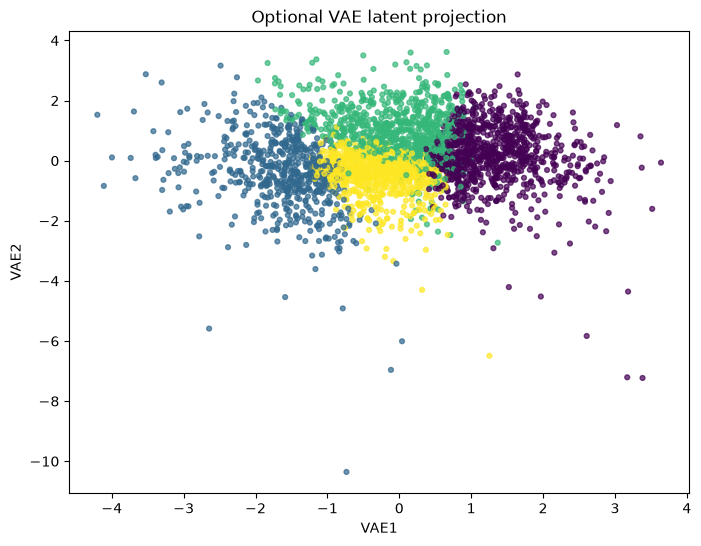

In [92]:
if cfg.RUN_VAE:
    from agri_market_state.vae import run_vae_projection
    model_df, vae_model = run_vae_projection(model_df, FEATURE_COLS, latent_dim=2, epochs=30, seed=RANDOM_STATE)
    plt.figure(figsize=(8, 6))
    plt.scatter(model_df["VAE1"], model_df["VAE2"], c=model_df["pca_regime"], s=12, alpha=0.7)
    plt.title("Optional VAE latent projection")
    plt.xlabel("VAE1")
    plt.ylabel("VAE2")
    plt.show()
else:
    print("VAE section skipped. Set cfg.RUN_VAE=True to run it.")